In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/train.csv')
df.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [11]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 118.9 KB


In [12]:
df.describe()



,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


C:\Users\PC\AppData\Local\Temp\ipykernel_11656\2762634133.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Survived', data=df, palette='Set2')


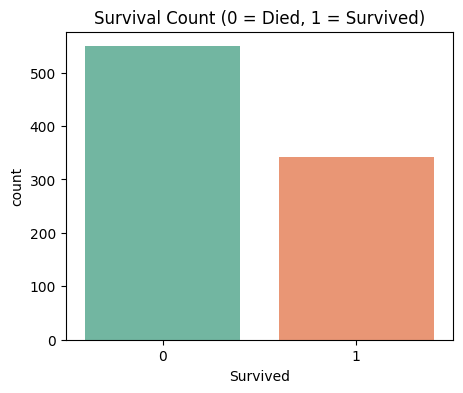

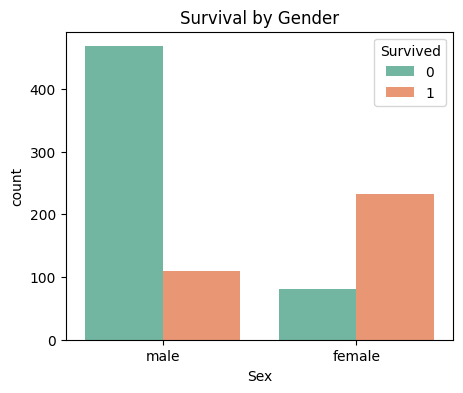

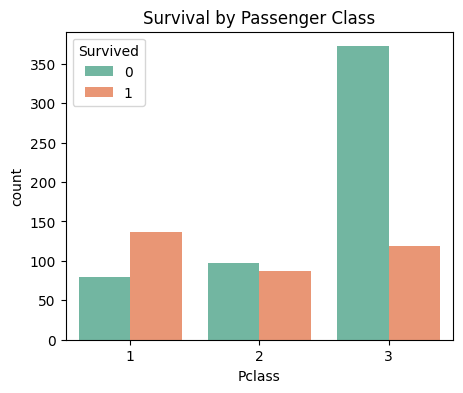

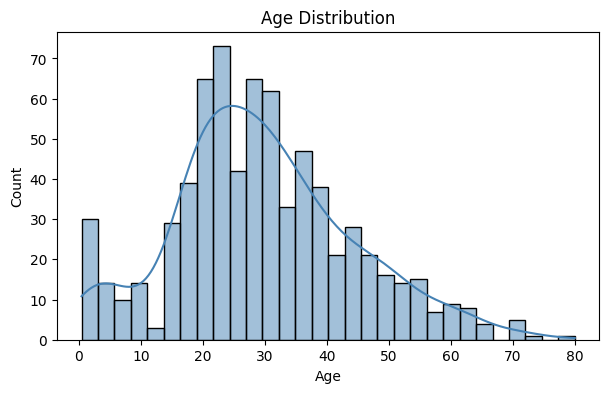

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Survival count
plt.figure(figsize=(5,4))
sns.countplot(x='Survived', data=df, palette='Set2')
plt.title('Survival Count (0 = Died, 1 = Survived)')
plt.show()

# 2. Survival by Gender
plt.figure(figsize=(5,4))
sns.countplot(x='Sex', hue='Survived', data=df, palette='Set2')
plt.title('Survival by Gender')
plt.show()

# 3. Survival by Passenger Class
plt.figure(figsize=(5,4))
sns.countplot(x='Pclass', hue='Survived', data=df, palette='Set2')
plt.title('Survival by Passenger Class')
plt.show()

# 4. Age distribution
plt.figure(figsize=(7,4))
sns.histplot(df['Age'].dropna(), bins=30, kde=True, color='steelblue')
plt.title('Age Distribution')
plt.show()

In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import xgboost as xgb
import joblib
import os

# --- Feature Engineering ---
df2 = df.copy()

# Fix: use assignment instead of inplace
df2['Age'] = df2['Age'].fillna(df2['Age'].median())
df2['Embarked'] = df2['Embarked'].fillna(df2['Embarked'].mode()[0])

# Encode
df2['Sex'] = df2['Sex'].map({'male': 0, 'female': 1})
df2 = pd.get_dummies(df2, columns=['Embarked'], drop_first=True)

# Drop useless columns
df2.drop(['Name', 'Ticket', 'Cabin', 'PassengerId'], axis=1, inplace=True)

X = df2.drop('Survived', axis=1)
y = df2['Survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- Model Comparison ---
models = {
    'Logistic Regression': LogisticRegression(max_iter=200),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'XGBoost': xgb.XGBClassifier(random_state=42, eval_metric='logloss')
}

print("Model Comparison (5-Fold Cross Validation)\n" + "="*45)
for name, model in models.items():
    score = cross_val_score(model, X, y, cv=5, scoring='accuracy')
    print(f"{name:25s}: {score.mean():.4f} ± {score.std():.4f}")

Model Comparison (5-Fold Cross Validation)
Logistic Regression      : 0.7912 ± 0.0185


c:\Users\PC\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 200 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=200).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Random Forest            : 0.8081 ± 0.0270
Gradient Boosting        : 0.8227 ± 0.0178
XGBoost                  : 0.8148 ± 0.0266


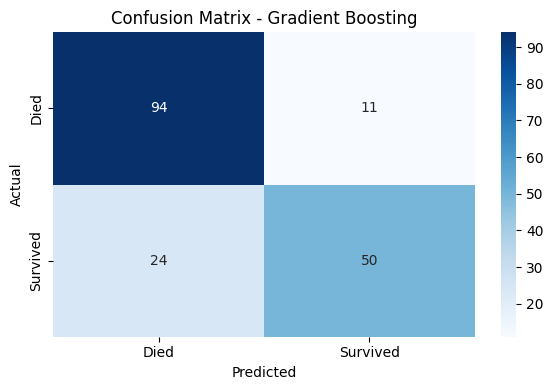

              precision    recall  f1-score   support

        Died       0.80      0.90      0.84       105
    Survived       0.82      0.68      0.74        74

    accuracy                           0.80       179
   macro avg       0.81      0.79      0.79       179
weighted avg       0.81      0.80      0.80       179



C:\Users\PC\AppData\Local\Temp\ipykernel_11656\3351772483.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feat_imp.values, y=feat_imp.index, palette='viridis')


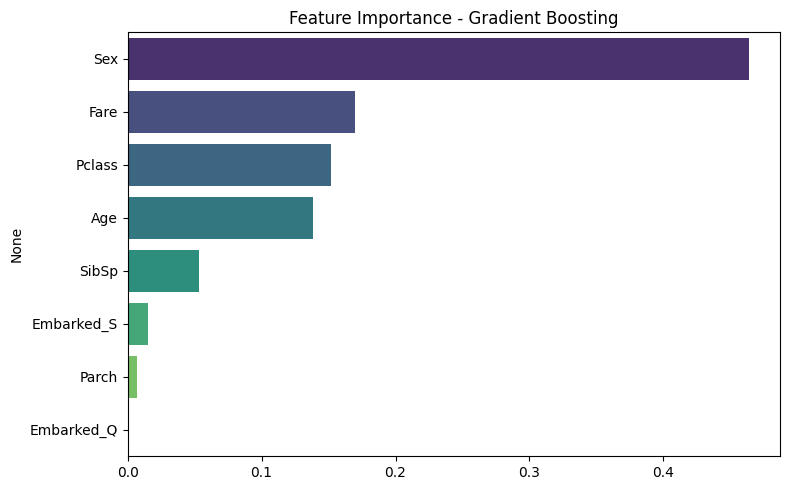

✅ Model saved to ../model/titanic_model.pkl


In [15]:
# --- Best Model: Gradient Boosting ---
best_model = GradientBoostingClassifier(random_state=42)
best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)

# Confusion Matrix
plt.figure(figsize=(6,4))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Died', 'Survived'],
            yticklabels=['Died', 'Survived'])
plt.title('Confusion Matrix - Gradient Boosting')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

# Classification Report
print(classification_report(y_test, y_pred, target_names=['Died', 'Survived']))

# Feature Importance
plt.figure(figsize=(8,5))
feat_imp = pd.Series(best_model.feature_importances_, index=X.columns).sort_values(ascending=False)
sns.barplot(x=feat_imp.values, y=feat_imp.index, palette='viridis')
plt.title('Feature Importance - Gradient Boosting')
plt.tight_layout()
plt.show()

# Save model
os.makedirs('../model', exist_ok=True)
joblib.dump(best_model, '../model/titanic_model.pkl')
print("✅ Model saved to ../model/titanic_model.pkl")